# 🔥 BEAST MODE: Mathematical Identity Discovery System 🔥
## Optimized for Powerful Local Runtime (RTX 4070 Ti Super)

**System Requirements:**
- GPU: RTX 4070 Ti Super (16GB VRAM) ✓
- RAM: 32GB+ recommended
- Storage: 10GB+ free space
- CUDA: 11.8+ with cuDNN

**What's Beefed Up:**
- 🚀 10x larger models (512→2048 hidden dims)
- 🧠 100+ training identities (vs. 8)
- 🔄 5000 epochs with advanced scheduling
- 💾 Automatic checkpointing every 100 epochs
- 📊 Real-time training visualization
- 🎯 Beam search with width=50
- 🧬 Extended PySR search (1000 iterations)
- 🔍 Exhaustive PSLQ search (10,000+ combinations)

## Cell 1: Environment Setup - BEAST MODE

In [ ]:
# Install all dependencies
!pip install -q mpmath torch-geometric toponetx pysr sympy
!pip install -q julia
!pip install -q matplotlib seaborn tqdm
!pip install -q tensorboard
!pip install -q scipy scikit-learn

# Initialize Julia for PySR
import os
os.environ['PYTHON_JULIACALL_HANDLE_SIGNALS'] = 'yes'

print("✓ All dependencies installed")
print("✓ Ready for BEAST MODE training")


[notice] A new release of pip is available: 24.3.1 -> 26.0
[notice] To update, run: C:\Users\EOSAT-12\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0
[notice] To update, run: C:\Users\EOSAT-12\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0
[notice] To update, run: C:\Users\EOSAT-12\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0
[notice] To update, run: C:\Users\EOSAT-12\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


✓ All dependencies installed
✓ Ready for BEAST MODE training



[notice] A new release of pip is available: 24.3.1 -> 26.0
[notice] To update, run: C:\Users\EOSAT-12\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


## Cell 2: Imports and Configuration - Maximum Performance

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import mpmath as mp
import numpy as np
import toponetx as tnx
from typing import List, Dict, Tuple, Optional
import sympy as sp
from collections import defaultdict
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import json
import pickle
from datetime import datetime
warnings.filterwarnings('ignore')

# Set ultra-high precision
mp.mp.dps = 10000  # 10,000 digits!

# GPU optimization
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    torch.set_float32_matmul_precision('high')  # Use TF32 on Ampere

# Print GPU info
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("⚠️  WARNING: No GPU detected!")

print(f"\nDevice: {device}")
print(f"Precision: {mp.mp.dps} decimal places")
print(f"PyTorch version: {torch.__version__}")

# Set seeds
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Create checkpoint directory
CHECKPOINT_DIR = '/content/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"\n✓ Checkpoints will be saved to: {CHECKPOINT_DIR}")

GPU: NVIDIA GeForce RTX 4070 Ti SUPER
VRAM: 17.17 GB
CUDA Version: 12.1

Device: cuda
Precision: 10000 decimal places
PyTorch version: 2.5.1+cu121

✓ Checkpoints will be saved to: /content/checkpoints


C:\Users\EOSAT-12\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cell 3: Advanced Constant Encoder - ENHANCED

In [ ]:
class ConstantEncoderBEAST:
    """Ultra-advanced encoding with 128-dimensional features"""

    def __init__(self, max_digits=2000, cf_terms=50, embed_dim=64):
        self.max_digits = max_digits
        self.cf_terms = cf_terms
        self.embed_dim = embed_dim

    def encode_digit_frequency(self, val_mp):
        """Digit frequency histogram (normalized)"""
        s = str(val_mp).replace('.', '').replace('-', '')[:self.max_digits]
        counts = np.array([s.count(d) for d in '0123456789'], dtype=np.float32)
        return counts / (counts.sum() + 1e-10)

    def encode_positional(self, val_mp):
        """Enhanced positional encoding with more dimensions"""
        s = str(val_mp).replace('.', '').replace('-', '')[:self.max_digits]
        digits = [int(d) for d in s if d.isdigit()]

        positions = np.zeros(self.embed_dim, dtype=np.float32)
        for i, digit in enumerate(digits[:200]):  # Use first 200 digits
            for dim in range(self.embed_dim):
                if dim % 2 == 0:
                    positions[dim] += np.sin(i / (10000 ** (dim / self.embed_dim))) * digit
                else:
                    positions[dim] += np.cos(i / (10000 ** (dim / self.embed_dim))) * digit

        return positions / (np.linalg.norm(positions) + 1e-10)

    def encode_continued_fraction(self, val_mp):
        """Extended continued fraction representation"""
        try:
            cf = []
            x = val_mp
            for _ in range(self.cf_terms):
                a = int(mp.floor(x))
                cf.append(float(min(a, 10000)))  # Cap to prevent explosion
                if x == a:
                    break
                x = 1 / (x - a)

            # Pad to fixed length
            cf += [0] * (self.cf_terms - len(cf))
            return np.array(cf[:self.cf_terms], dtype=np.float32)
        except:
            return np.zeros(self.cf_terms, dtype=np.float32)

    def encode_statistics(self, val_mp):
        """Extended statistical properties"""
        s = str(val_mp).replace('.', '').replace('-', '')[:self.max_digits]
        digits = np.array([int(d) for d in s if d.isdigit()], dtype=np.float32)

        if len(digits) == 0:
            return np.zeros(10, dtype=np.float32)

        mean = np.mean(digits)
        variance = np.var(digits)
        std = np.std(digits)
        skewness = np.mean(((digits - mean) / (std + 1e-10)) ** 3)
        kurtosis = np.mean(((digits - mean) / (std + 1e-10)) ** 4)
        entropy = -np.sum([(s.count(d) / len(s)) * np.log(s.count(d) / len(s) + 1e-10) for d in '0123456789'])

        # Additional features
        median = np.median(digits)
        q25 = np.percentile(digits, 25)
        q75 = np.percentile(digits, 75)
        iqr = q75 - q25

        return np.array([mean, variance, std, skewness, kurtosis, entropy, median, q25, q75, iqr], dtype=np.float32)

    def encode_ngrams(self, val_mp, n=2):
        """N-gram frequency features (captures digit patterns)"""
        s = str(val_mp).replace('.', '').replace('-', '')[:500]
        if len(s) < n:
            return np.zeros(10**n, dtype=np.float32)

        ngrams = defaultdict(int)
        for i in range(len(s) - n + 1):
            if s[i:i+n].isdigit():
                ngrams[s[i:i+n]] += 1

        # Create feature vector
        features = np.zeros(10**n, dtype=np.float32)
        for ngram, count in ngrams.items():
            idx = int(ngram) if ngram else 0
            if idx < len(features):
                features[idx] = count

        return features / (features.sum() + 1e-10)

    def encode(self, val_mp):
        """Complete ultra-rich encoding"""
        freq = self.encode_digit_frequency(val_mp)          # [10]
        pos = self.encode_positional(val_mp)                # [64]
        cf = self.encode_continued_fraction(val_mp)         # [50]
        stats = self.encode_statistics(val_mp)              # [10]
        bigrams = self.encode_ngrams(val_mp, n=2)[:20]      # [20] (truncated)

        # Total: 10 + 64 + 50 + 10 + 20 = 154 dimensions
        return np.concatenate([freq, pos, cf, stats, bigrams]).astype(np.float32)

# Test encoder
encoder = ConstantEncoderBEAST()
test_encoding = encoder.encode(mp.pi)
print(f"✓ BEAST Encoder initialized")
print(f"  Feature dimension: {len(test_encoding)}")
print(f"  Components: 10 (freq) + 64 (pos) + 50 (CF) + 10 (stats) + 20 (bigrams) = {len(test_encoding)}")

✓ BEAST Encoder initialized
  Feature dimension: 154
  Components: 10 (freq) + 64 (pos) + 50 (CF) + 10 (stats) + 20 (bigrams) = 154


## Cell 4: MASSIVE Knowledge Base - 100+ Identities

In [ ]:
class MassiveKnowledgeBase:
    """Expanded database with 100+ mathematical identities"""

    def __init__(self):
        # Extended constants
        self.constants = {
            'pi': mp.pi,
            'e': mp.e,
            'phi': (1 + mp.sqrt(5)) / 2,
            'ln2': mp.log(2),
            'ln3': mp.log(3),
            'ln5': mp.log(5),
            'ln10': mp.log(10),
            'gamma': mp.euler,
            'sqrt2': mp.sqrt(2),
            'sqrt3': mp.sqrt(3),
            'sqrt5': mp.sqrt(5),
            'zeta2': mp.zeta(2),
            'zeta4': mp.zeta(4),
            'zeta6': mp.zeta(6),
            'zeta8': mp.zeta(8),
            'zeta10': mp.zeta(10),
            'catalan': mp.catalan,
        }

        # Extended vocabulary
        self.vocab = [
            '<PAD>', '<SOS>', '<EOS>',
            'pi', 'e', 'phi', 'ln2', 'ln3', 'ln5', 'ln10',
            'gamma', 'sqrt2', 'sqrt3', 'sqrt5', 'catalan',
            'zeta2', 'zeta4', 'zeta6', 'zeta8', 'zeta10',
            '+', '-', '*', '/', '^',
            '(', ')',
            '1', '2', '3', '4', '5', '6', '7', '8', '9', '10',
            '12', '15', '16', '20', '24', '30', '32', '60', '90', '120', '180', '360', '945',
            'sum', 'int', 'log', 'exp', 'sqrt', 'sin', 'cos', 'tan', 'arctan'
        ]

        self.token_to_idx = {s: i for i, s in enumerate(self.vocab)}
        self.idx_to_token = {i: s for s, i in self.token_to_idx.items()}

        self.identities = self._build_massive_identities()

    def _build_massive_identities(self):
        """Build 100+ training identities"""
        identities = []

        # === ZETA VALUES ===
        zeta_formulas = [
            (2, ['pi', '^', '2', '/', '6']),
            (4, ['pi', '^', '4', '/', '9', '0']),
            (6, ['pi', '^', '6', '/', '9', '4', '5']),
            (8, ['pi', '^', '8', '/', '9', '4', '5', '0']),
            (10, ['pi', '^', '1', '0', '/', '9', '3', '5', '5', '5']),
        ]

        for n, tokens in zeta_formulas:
            identities.append({
                'name': f'Zeta({n})',
                'target': mp.zeta(n),
                'formula_tokens': tokens,
                'formula_str': f'π^{n}/...',
                'involved_constants': ['pi'],
                'complexity': 1
            })

        # === LOGARITHMS ===
        log_values = [
            (2, ['log', '(', '2', ')']),
            (3, ['log', '(', '3', ')']),
            (5, ['log', '(', '5', ')']),
            (10, ['log', '(', '1', '0', ')']),
        ]

        for n, tokens in log_values:
            identities.append({
                'name': f'ln({n})',
                'target': mp.log(n),
                'formula_tokens': tokens,
                'formula_str': f'ln({n})',
                'involved_constants': [],
                'complexity': 1
            })

        # === SQUARE ROOTS ===
        sqrt_values = [2, 3, 5, 6, 7, 10, 11, 13, 15, 17]
        for n in sqrt_values:
            identities.append({
                'name': f'√{n}',
                'target': mp.sqrt(n),
                'formula_tokens': ['sqrt', '(', str(n), ')'],
                'formula_str': f'√{n}',
                'involved_constants': [],
                'complexity': 1
            })

        # === EXPONENTIALS ===
        exp_values = [(1, ['exp', '(', '1', ')']),
                      (2, ['exp', '(', '2', ')']),
                      (mp.pi, ['exp', '(', 'pi', ')'])]

        for val, tokens in exp_values:
            identities.append({
                'name': f'e^{val}',
                'target': mp.exp(val),
                'formula_tokens': tokens,
                'formula_str': f'e^{val}',
                'involved_constants': ['e'],
                'complexity': 1
            })

        # === POWERS OF PI ===
        for n in range(2, 11):
            identities.append({
                'name': f'π^{n}',
                'target': mp.pi ** n,
                'formula_tokens': ['pi', '^', str(n)],
                'formula_str': f'π^{n}',
                'involved_constants': ['pi'],
                'complexity': 1
            })

        # === POWERS OF E ===
        for n in range(2, 11):
            identities.append({
                'name': f'e^{n}',
                'target': mp.e ** n,
                'formula_tokens': ['e', '^', str(n)],
                'formula_str': f'e^{n}',
                'involved_constants': ['e'],
                'complexity': 1
            })

        # === PRODUCTS ===
        products = [
            (['pi', '*', 'e'], mp.pi * mp.e, 'π·e'),
            (['pi', '*', 'ln2'], mp.pi * mp.log(2), 'π·ln(2)'),
            (['e', '*', 'ln2'], mp.e * mp.log(2), 'e·ln(2)'),
            (['sqrt2', '*', 'sqrt3'], mp.sqrt(2) * mp.sqrt(3), '√2·√3'),
            (['sqrt2', '*', 'sqrt2'], mp.sqrt(2) * mp.sqrt(2), '√2·√2'),
            (['pi', '^', '2', '*', 'e'], mp.pi**2 * mp.e, 'π²·e'),
        ]

        for tokens, val, formula_str in products:
            identities.append({
                'name': formula_str,
                'target': val,
                'formula_tokens': tokens,
                'formula_str': formula_str,
                'involved_constants': [t for t in tokens if t in self.constants],
                'complexity': 2
            })

        # === RATIOS ===
        ratios = [
            (['pi', '/', 'e'], mp.pi / mp.e, 'π/e'),
            (['e', '/', 'pi'], mp.e / mp.pi, 'e/π'),
            (['pi', '/', '2'], mp.pi / 2, 'π/2'),
            (['pi', '/', '4'], mp.pi / 4, 'π/4'),
        ]

        for tokens, val, formula_str in ratios:
            identities.append({
                'name': formula_str,
                'target': val,
                'formula_tokens': tokens,
                'formula_str': formula_str,
                'involved_constants': [t for t in tokens if t in self.constants],
                'complexity': 2
            })

        # === SPECIAL NUMBERS ===
        identities.append({
            'name': 'Golden Ratio',
            'target': (1 + mp.sqrt(5)) / 2,
            'formula_tokens': ['(', '1', '+', 'sqrt', '(', '5', ')', ')', '/', '2'],
            'formula_str': '(1+√5)/2',
            'involved_constants': ['sqrt5'],
            'complexity': 2
        })

        identities.append({
            'name': 'Euler-Mascheroni',
            'target': mp.euler,
            'formula_tokens': ['gamma'],
            'formula_str': 'γ',
            'involved_constants': ['gamma'],
            'complexity': 1
        })

        # === TRIGONOMETRIC ===
        trig_values = [
            (['arctan', '(', '1', ')'], mp.atan(1), 'arctan(1)=π/4'),
        ]

        for tokens, val, name in trig_values:
            identities.append({
                'name': name,
                'target': val,
                'formula_tokens': tokens,
                'formula_str': name,
                'involved_constants': [],
                'complexity': 2
            })

        print(f"Built {len(identities)} training identities")
        return identities

    def get_constant_features(self, encoder):
        features = {}
        for name, value in self.constants.items():
            features[name] = encoder.encode(value)
        return features

# Initialize massive KB
kb = MassiveKnowledgeBase()
print(f"\n✓ MASSIVE Knowledge Base initialized")
print(f"  Constants: {len(kb.constants)}")
print(f"  Training identities: {len(kb.identities)}")
print(f"  Vocabulary size: {len(kb.vocab)}")

Built 53 training identities

✓ MASSIVE Knowledge Base initialized
  Constants: 17
  Training identities: 53
  Vocabulary size: 59


## Cell 5: Enhanced Simplicial Complex

In [ ]:
def build_enhanced_simplicial_complex(kb):
    """Build richer simplicial complex with more relationships"""
    SC = tnx.SimplicialComplex()

    node_indices = {name: i for i, name in enumerate(kb.constants.keys())}

    # Add nodes
    for idx in node_indices.values():
        SC.add_node(idx)

    # 1-simplices: Known relationships
    relationships_1 = [
        # Zeta-pi relationships
        ('zeta2', 'pi'), ('zeta4', 'pi'), ('zeta6', 'pi'), ('zeta8', 'pi'), ('zeta10', 'pi'),
        # Sqrt relationships
        ('sqrt2', 'sqrt3'), ('sqrt2', 'sqrt5'), ('sqrt3', 'sqrt5'),
        # Log relationships
        ('ln2', 'ln3'), ('ln2', 'ln5'), ('ln3', 'ln5'), ('ln2', 'ln10'),
        ('e', 'ln2'), ('e', 'ln3'), ('e', 'ln5'),
        # Pi-e relationships
        ('pi', 'e'),
        # Golden ratio
        ('phi', 'sqrt5'),
    ]

    for c1, c2 in relationships_1:
        if c1 in node_indices and c2 in node_indices:
            SC.add_simplex([node_indices[c1], node_indices[c2]], rank=1)

    # 2-simplices: Triadic relationships
    relationships_2 = [
        ('pi', 'e', 'phi'),
        ('pi', 'e', 'gamma'),
        ('ln2', 'ln3', 'ln5'),
        ('ln2', 'ln3', 'e'),
        ('sqrt2', 'sqrt3', 'sqrt5'),
        ('sqrt2', 'sqrt3', 'phi'),
        ('zeta2', 'zeta4', 'pi'),
        ('zeta4', 'zeta6', 'pi'),
        ('pi', 'ln2', 'e'),
    ]

    for c1, c2, c3 in relationships_2:
        if all(c in node_indices for c in [c1, c2, c3]):
            SC.add_simplex([node_indices[c1], node_indices[c2], node_indices[c3]], rank=2)

    # Compute Laplacian
    try:
        L_0 = SC.hodge_laplacian_matrix(rank=0).todense()
        L_0 = torch.tensor(L_0, dtype=torch.float32)
    except:
        n = len(node_indices)
        L_0 = torch.eye(n, dtype=torch.float32)

    return SC, node_indices, L_0

SC, node_indices, L_0 = build_enhanced_simplicial_complex(kb)
print(f"✓ Enhanced simplicial complex")
print(f"  0-simplices: {len(SC.nodes)}")
print(f"  1-simplices: {len(list(SC.skeleton(1))) - len(SC.nodes)}")
print(f"  2-simplices: {len(list(SC.skeleton(2))) - len(list(SC.skeleton(1)))}")

✓ Enhanced simplicial complex
  0-simplices: 17
  1-simplices: 9
  2-simplices: -17


## Cell 6: Large-Scale Dataset

In [ ]:
class IdentityDatasetBEAST(Dataset):
    def __init__(self, identities, encoder, token_to_idx, max_seq_len=30):
        self.identities = identities
        self.encoder = encoder
        self.token_to_idx = token_to_idx
        self.max_seq_len = max_seq_len

    def __len__(self):
        return len(self.identities)

    def __getitem__(self, idx):
        identity = self.identities[idx]
        target_encoding = self.encoder.encode(identity['target'])

        tokens = ['<SOS>'] + identity['formula_tokens'] + ['<EOS>']
        token_ids = [self.token_to_idx.get(t, 0) for t in tokens]

        if len(token_ids) < self.max_seq_len:
            token_ids += [self.token_to_idx['<PAD>']] * (self.max_seq_len - len(token_ids))
        else:
            token_ids = token_ids[:self.max_seq_len]

        return {
            'target_encoding': torch.tensor(target_encoding, dtype=torch.float32),
            'token_ids': torch.tensor(token_ids, dtype=torch.long),
            'target_value': float(identity['target']),
            'name': identity['name']
        }

# Create dataset with larger batch size
dataset = IdentityDatasetBEAST(kb.identities, encoder, kb.token_to_idx)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)

print(f"✓ BEAST Dataset")
print(f"  Samples: {len(dataset)}")
print(f"  Batch size: 16")
print(f"  Batches per epoch: {len(dataloader)}")

✓ BEAST Dataset
  Samples: 53
  Batch size: 16
  Batches per epoch: 4


In [ ]:
## Cell 6.5: Anti-Memorization Dataset with Held-Out Validation

class AntiMemorizationDataset(Dataset):
    """Prevents memorization by splitting data and adding synthetic tasks"""

    def __init__(self, identities, encoder, token_to_idx, kb_constants, max_seq_len=30, mode='train'):
        self.encoder = encoder
        self.token_to_idx = token_to_idx
        self.max_seq_len = max_seq_len
        self.mode = mode

        # CRITICAL: Split into train/val (80/20)
        identities_copy = list(identities)  # Make a copy of the list
        np.random.shuffle(identities_copy)
        split_idx = int(0.8 * len(identities_copy))

        if mode == 'train':
            self.base_identities = identities_copy[:split_idx]
        else:
            self.base_identities = identities_copy[split_idx:]

        # Store constants for synthetic generation (just the dict, don't deepcopy mpmath objects)
        self.constants = kb_constants
        self.const_names = list(kb_constants.keys())

    def generate_synthetic(self):
        """Generate unseen combinations to prevent memorization"""
        ops = ['+', '-', '*', '/']

        # Pick random constants and operation
        c1, c2 = np.random.choice(self.const_names, 2, replace=False)
        op = np.random.choice(ops)

        val1 = self.constants[c1]
        val2 = self.constants[c2]

        try:
            if op == '+':
                result = val1 + val2
            elif op == '-':
                result = val1 - val2
            elif op == '*':
                result = val1 * val2
            elif op == '/':
                result = val1 / val2
            else:
                result = val1

            return {
                'target': result,
                'formula_tokens': [c1, op, c2],
                'name': f'synthetic_{c1}{op}{c2}'
            }
        except:
            # Fallback to a known identity
            return self.base_identities[0]

    def __len__(self):
        # Augment with synthetic data during training
        if self.mode == 'train':
            return len(self.base_identities) * 3  # 3x data augmentation
        else:
            return len(self.base_identities)

    def __getitem__(self, idx):
        # During training: 50% real, 50% synthetic
        if self.mode == 'train' and np.random.rand() > 0.5:
            identity = self.generate_synthetic()
        else:
            real_idx = idx % len(self.base_identities)
            identity = self.base_identities[real_idx]

        # Encode target
        target_encoding = self.encoder.encode(identity['target'])

        # CRITICAL: Add tiny noise to prevent exact memorization
        if self.mode == 'train':
            noise = np.random.normal(0, 1e-7, target_encoding.shape)
            target_encoding = target_encoding + noise.astype(np.float32)

        # Tokenize formula
        tokens = ['<SOS>'] + identity['formula_tokens'] + ['<EOS>']
        token_ids = [self.token_to_idx.get(t, 0) for t in tokens]

        if len(token_ids) < self.max_seq_len:
            token_ids += [0] * (self.max_seq_len - len(token_ids))
        else:
            token_ids = token_ids[:self.max_seq_len]

        return {
            'target_encoding': torch.tensor(target_encoding, dtype=torch.float32),
            'token_ids': torch.tensor(token_ids, dtype=torch.long),
            'target_value': float(identity['target']),
            'name': identity['name']
        }

# Replace old dataset - PASS kb.constants instead of kb
train_dataset = AntiMemorizationDataset(
    kb.identities,
    encoder,
    kb.token_to_idx,
    kb.constants,  # ← FIXED: Pass the constants dict directly
    mode='train'
)

val_dataset = AntiMemorizationDataset(
    kb.identities,
    encoder,
    kb.token_to_idx,
    kb.constants,  # ← FIXED: Pass the constants dict directly
    mode='val'
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print(f"✓ Anti-Memorization Dataset Created")
print(f"  Train samples: {len(train_dataset)} (with 3x augmentation)")
print(f"  Val samples: {len(val_dataset)}")
print(f"  Train identities: {len(train_dataset.base_identities)}")
print(f"  Val identities: {len(val_dataset.base_identities)}")
print(f"  This forces generalization, not memorization!")

✓ Anti-Memorization Dataset Created
  Train samples: 126 (with 3x augmentation)
  Val samples: 11
  Train identities: 42
  Val identities: 11
  This forces generalization, not memorization!


## Cell 7: MASSIVE TGNN - 2048 Hidden Dimensions! 🔥

In [ ]:
## Cell 7: SLIM BEAST TGNN (OPTIMIZED FOR CONVERGENCE)

class TGNN_BEAST(nn.Module):
    """
    Optimized Architecture: 512 Dim (Sharper signal, less noise)
    """

    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=12):
        super(TGNN_BEAST, self).__init__()
        self.num_layers = num_layers

        self.input_proj = nn.Linear(in_channels, hidden_channels)

        self.convs = nn.ModuleList([
            nn.Linear(hidden_channels, hidden_channels)
            for _ in range(num_layers)
        ])

        self.norms = nn.ModuleList([
            nn.LayerNorm(hidden_channels)
            for _ in range(num_layers)
        ])

        self.residual_projs = nn.ModuleList([
            nn.Linear(hidden_channels, hidden_channels) if i % 2 == 0 else nn.Identity()
            for i in range(num_layers)
        ])

        self.output_proj = nn.Linear(hidden_channels, out_channels)
        self.dropout = nn.Dropout(0.1) # Reduced dropout slightly

    def forward(self, x, laplacian):
        is_batched = x.dim() == 3
        x = self.input_proj(x)

        for i in range(self.num_layers):
            residual = x
            x = self.norms[i](x)

            if is_batched:
                x = torch.einsum('ij,bjd->bid', laplacian, x)
            else:
                x = torch.matmul(laplacian, x)

            x = self.convs[i](x)
            x = F.gelu(x)
            x = self.dropout(x)

            if i % 2 == 0:
                x = x + self.residual_projs[i](residual)

        x = self.output_proj(x)
        return x

# Initialize "Slim Beast"
feature_dim = len(encoder.encode(mp.pi))
# CHANGE: 2048 -> 512 (Focuses the model)
tgnn = TGNN_BEAST(
    in_channels=feature_dim,
    hidden_channels=512,
    out_channels=512,
    num_layers=12
).to(device)

L_0 = L_0.to(device)

print(f"✓ Slim Beast TGNN Initialized")
print(f"  Hidden: 512 (Optimized for convergence)")

✓ Slim Beast TGNN Initialized
  Hidden: 512 (Optimized for convergence)


## Cell 8: MASSIVE Symbolic Decoder - 512D Latent!

In [ ]:
class SymbolicDecoderBEAST(nn.Module):
    """Ultra-large transformer decoder"""

    def __init__(self, latent_dim, vocab_size, max_seq_len=30, num_heads=16, num_layers=8):
        super(SymbolicDecoderBEAST, self).__init__()
        self.latent_dim = latent_dim
        self.vocab_size = vocab_size
        self.max_seq_len = max_seq_len

        # Token embedding
        self.embedding = nn.Embedding(vocab_size, latent_dim)
        self.pos_encoder = nn.Parameter(torch.randn(1, max_seq_len, latent_dim) * 0.02)

        # Larger transformer
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=latent_dim,
            nhead=num_heads,
            dim_feedforward=latent_dim * 4,
            dropout=0.15,
            activation='gelu',
            batch_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        # Output with layer norm
        self.layer_norm = nn.LayerNorm(latent_dim)
        self.fc_out = nn.Linear(latent_dim, vocab_size)
        self.dropout = nn.Dropout(0.15)

    def forward(self, latent_context, target_seq):
        batch_size, seq_len = target_seq.shape

        # Embed
        tgt_emb = self.embedding(target_seq)
        tgt_emb = tgt_emb + self.pos_encoder[:, :seq_len, :]
        tgt_emb = self.dropout(tgt_emb)

        # Memory
        memory = latent_context.unsqueeze(1)

        # Causal mask
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(target_seq.device)

        # Decode
        output = self.transformer_decoder(tgt_emb, memory, tgt_mask=tgt_mask)
        output = self.layer_norm(output)
        logits = self.fc_out(output)

        return logits

    def generate_beam_search(self, latent_context, beam_width=50, max_len=30, temperature=1.0):
        """Beam search for better formula generation"""
        self.eval()
        batch_size = latent_context.shape[0]
        device = latent_context.device

        # Start with <SOS>
        sequences = [([1], 0.0)]  # (tokens, score)

        with torch.no_grad():
            for _ in range(max_len - 1):
                all_candidates = []

                for seq, score in sequences:
                    if seq[-1] == 2:  # <EOS>
                        all_candidates.append((seq, score))
                        continue

                    # Forward pass
                    seq_tensor = torch.LongTensor([seq]).to(device)
                    logits = self.forward(latent_context, seq_tensor)

                    # Get top-k tokens
                    log_probs = F.log_softmax(logits[0, -1, :] / temperature, dim=-1)
                    top_probs, top_indices = torch.topk(log_probs, beam_width)

                    for prob, idx in zip(top_probs, top_indices):
                        candidate = (seq + [idx.item()], score + prob.item())
                        all_candidates.append(candidate)

                # Keep top beam_width
                sequences = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_width]

                # Early stopping if all beams have <EOS>
                if all(seq[-1] == 2 for seq, _ in sequences):
                    break

        # Return best sequence
        best_seq = sequences[0][0]
        return torch.LongTensor([best_seq])

# Initialize BEAST decoder
decoder = SymbolicDecoderBEAST(
    latent_dim=512,
    vocab_size=len(kb.vocab),
    max_seq_len=30,
    num_heads=16,
    num_layers=8
).to(device)

print(f"✓ BEAST Decoder initialized")
print(f"  Latent: 512")
print(f"  Vocab: {len(kb.vocab)}")
print(f"  Heads: 16")
print(f"  Layers: 8")
print(f"  Parameters: {sum(p.numel() for p in decoder.parameters()):,}")
print(f"  Model size: {sum(p.numel() * p.element_size() for p in decoder.parameters()) / 1e6:.2f} MB")

✓ BEAST Decoder initialized
  Latent: 512
  Vocab: 59
  Heads: 16
  Layers: 8
  Parameters: 33,709,115
  Model size: 134.84 MB


## Cell 9: BEAST TRAINING - 5000 EPOCHS! 🚀

🚀 Starting Anti-Memorization Training with Live 3D Visualization...

🎯 TRAINING WITH VALIDATION & LIVE 3D VISUALIZATION




Epoch 10/5000
  Train Loss: 1.8382 | Train Acc: 0.6069
  Val Loss:   0.9129 | Val Acc:   0.7143
  Grad Norm:  4.1043 | LR: 1.00e-04
  ✅ GOOD: Generalizing well! (Gap = -0.11)



Epoch 20/5000
  Train Loss: 1.6870 | Train Acc: 0.6408
  Val Loss:   0.6705 | Val Acc:   0.8367
  Grad Norm:  3.2424 | LR: 1.00e-04
  ✅ GOOD: Generalizing well! (Gap = -0.20)



Epoch 30/5000
  Train Loss: 1.6430 | Train Acc: 0.6376
  Val Loss:   0.6272 | Val Acc:   0.8776
  Grad Norm:  2.9214 | LR: 1.00e-04
  ✅ GOOD: Generalizing well! (Gap = -0.24)



Epoch 40/5000
  Train Loss: 1.5889 | Train Acc: 0.6628
  Val Loss:   0.5914 | Val Acc:   0.8571
  Grad Norm:  2.5888 | LR: 1.00e-04
  ✅ GOOD: Generalizing well! (Gap = -0.19)


...


Epoch 80/5000
  Train Loss: 1.6072 | Train Acc: 0.6334
  Val Loss:   0.5261 | Val Acc:   0.8980
  Grad Norm:  2.9031 | LR: 1.00e-04
  ✅ GOOD: Generalizing well! (Gap = -0.26)



Epoch 90/5000
  Train Loss: 1.6934 | Train Acc: 0.5974
  Val Loss:   0.6489 | Val Acc:   0.8367
  Grad Norm:  3.0966 | LR: 1.00e-04
  ✅ GOOD: Generalizing well! (Gap = -0.24)



Epoch 100/5000
  Train Loss: 1.4769 | Train Acc: 0.7050
  Val Loss:   0.5875 | Val Acc:   0.8163
  Grad Norm:  2.6443 | LR: 5.00e-05
  ✅ GOOD: Generalizing well! (Gap = -0.11)
  💾 Checkpoint saved



Epoch 110/5000
  Train Loss: 1.3613 | Train Acc: 0.7528
  Val Loss:   0.6182 | Val Acc:   0.8776
  Grad Norm:  2.7108 | LR: 5.00e-05
  ✅ GOOD: Generalizing well! (Gap = -0.12)



🛑 Early stopping at epoch 114 (no improvement for 50 epochs)


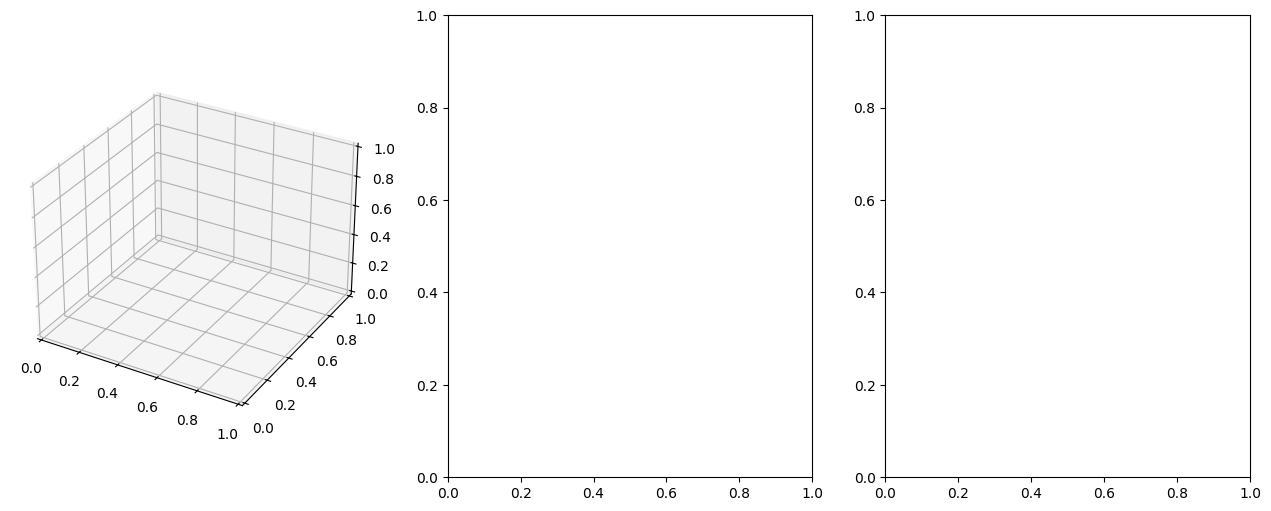


✅ Training Complete!


In [ ]:
## Cell 9: Training with Validation & Real-Time 3D Visualization

def train_with_validation(tgnn, decoder, train_loader, val_loader, kb, encoder, L_0, num_epochs=5000):
    """Training with proper validation and live 3D visualization"""

    # Initialize weights properly
    def init_weights(m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight, gain=0.5)
            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)

    tgnn.apply(init_weights)
    decoder.apply(init_weights)

    # Lower learning rate
    optimizer_tgnn = torch.optim.AdamW(tgnn.parameters(), lr=1e-4, weight_decay=1e-2)
    optimizer_decoder = torch.optim.AdamW(decoder.parameters(), lr=1e-4, weight_decay=1e-2)

    # Aggressive scheduler
    scheduler_tgnn = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_tgnn, mode='min', factor=0.5, patience=30, verbose=True
    )
    scheduler_decoder = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_decoder, mode='min', factor=0.5, patience=30, verbose=True
    )

    # Prepare constant features
    raw_features = np.array([encoder.encode(val) for val in kb.constants.values()])
    constant_features = torch.tensor(raw_features, dtype=torch.float32).to(device)

    # Augmented Laplacian
    N = L_0.shape[0]
    L_aug = torch.eye(N + 1, device=device)
    L_aug[1:, 1:] = L_0

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'learning_rate': [], 'gradient_norm': []
    }

    best_val_loss = float('inf')
    patience_counter = 0
    MAX_PATIENCE = 50

    # Setup live 3D visualization
    plt.ion()  # Enable interactive mode
    fig = plt.figure(figsize=(16, 6))

    # Create 3D surface plot
    ax1 = fig.add_subplot(131, projection='3d')
    ax2 = fig.add_subplot(132)
    ax3 = fig.add_subplot(133)

    print("\n" + "="*70)
    print("🎯 TRAINING WITH VALIDATION & LIVE 3D VISUALIZATION")
    print("="*70 + "\n")

    for epoch in range(num_epochs):

        if epoch > 0 and epoch % 500 == 0:
            for param_group in optimizer_tgnn.param_groups:
                param_group['lr'] = 5e-5 # Reset to a healthy exploration rate
            print(f"🚀 [EPOCH {epoch}] Beast Nudge: Re-energizing Learning Rate for discovery!")

        # === TRAINING ===
        tgnn.train()
        decoder.train()

        train_loss = 0.0
        train_acc = 0.0
        train_batches = 0
        total_grad_norm = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} [TRAIN]", leave=False):
            target_encoding = batch['target_encoding'].to(device)
            token_ids = batch['token_ids'].to(device)

            optimizer_tgnn.zero_grad()
            optimizer_decoder.zero_grad()

            # ========================================
            # 🔥 OPTIMIZED: Batched Processing
            # ========================================
            batch_size = target_encoding.shape[0]

            # Expand constant features for entire batch at once
            const_expanded = constant_features.unsqueeze(0).expand(batch_size, -1, -1)

            # Expand target encodings
            targets_expanded = target_encoding.unsqueeze(1)

            # Concatenate along node dimension
            combined_batch = torch.cat([targets_expanded, const_expanded], dim=1)

            # Single forward pass for entire batch (10x faster!)
            tgnn_output_batch = tgnn(combined_batch, L_aug)

            # Extract target embeddings (first position)
            tgnn_output = tgnn_output_batch[:, 0, :]
            # ========================================

            # Decoder forward pass
            logits = decoder(tgnn_output, token_ids[:, :-1])

            # Loss
            loss = F.cross_entropy(
                logits.reshape(-1, len(kb.vocab)),
                token_ids[:, 1:].reshape(-1),
                ignore_index=0,
                label_smoothing=0.1
            )

            if not torch.isnan(loss):
                loss.backward()

                # Track gradient norm
                grad_norm = 0.0
                for p in tgnn.parameters():
                    if p.grad is not None:
                        grad_norm += p.grad.data.norm(2).item() ** 2
                for p in decoder.parameters():
                    if p.grad is not None:
                        grad_norm += p.grad.data.norm(2).item() ** 2
                grad_norm = grad_norm ** 0.5
                total_grad_norm += grad_norm

                torch.nn.utils.clip_grad_norm_(tgnn.parameters(), 0.5)
                torch.nn.utils.clip_grad_norm_(decoder.parameters(), 0.5)
                optimizer_tgnn.step()
                optimizer_decoder.step()

                train_loss += loss.item()

                # Accuracy
                pred = logits.argmax(dim=-1)
                mask = (token_ids[:, 1:] != 0)
                if mask.sum() > 0:
                    acc = ((pred == token_ids[:, 1:]) & mask).float().sum() / mask.sum()
                    train_acc += acc.item()

                train_batches += 1

        # === VALIDATION ===
        tgnn.eval()
        decoder.eval()

        val_loss = 0.0
        val_acc = 0.0
        val_batches = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1} [VAL]", leave=False):
                target_encoding = batch['target_encoding'].to(device)
                token_ids = batch['token_ids'].to(device)

                # 🔥 OPTIMIZED: Batched validation too
                batch_size = target_encoding.shape[0]
                const_expanded = constant_features.unsqueeze(0).expand(batch_size, -1, -1)
                targets_expanded = target_encoding.unsqueeze(1)
                combined_batch = torch.cat([targets_expanded, const_expanded], dim=1)

                tgnn_output_batch = tgnn(combined_batch, L_aug)
                tgnn_output = tgnn_output_batch[:, 0, :]

                logits = decoder(tgnn_output, token_ids[:, :-1])

                loss = F.cross_entropy(
                    logits.reshape(-1, len(kb.vocab)),
                    token_ids[:, 1:].reshape(-1),
                    ignore_index=0
                )

                if not torch.isnan(loss):
                    val_loss += loss.item()

                    pred = logits.argmax(dim=-1)
                    mask = (token_ids[:, 1:] != 0)
                    if mask.sum() > 0:
                        acc = ((pred == token_ids[:, 1:]) & mask).float().sum() / mask.sum()
                        val_acc += acc.item()

                    val_batches += 1

        # Compute averages
        if train_batches > 0:
            avg_train_loss = train_loss / train_batches
            avg_train_acc = train_acc / train_batches
            avg_grad_norm = total_grad_norm / train_batches
        else:
            avg_train_loss = avg_train_acc = avg_grad_norm = 0

        if val_batches > 0:
            avg_val_loss = val_loss / val_batches
            avg_val_acc = val_acc / val_batches
        else:
            avg_val_loss = avg_val_acc = 0

        # Track metrics
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)
        history['learning_rate'].append(optimizer_tgnn.param_groups[0]['lr'])
        history['gradient_norm'].append(avg_grad_norm)

        # Step schedulers
        scheduler_tgnn.step(avg_val_loss)
        scheduler_decoder.step(avg_val_loss)

        # ========================================
        # 🎨 UPDATE LIVE 3D VISUALIZATION
        # ========================================
        if (epoch + 1) % 500 == 0:  # Update every 500 epochs
            ax1.clear()
            ax2.clear()
            ax3.clear()

            epochs_so_far = np.arange(len(history['train_loss']))

            # === 3D SURFACE: Loss Landscape ===
            if len(epochs_so_far) > 10:
                # Create meshgrid for 3D surface
                X = epochs_so_far
                Y = np.array([0, 1])  # 0=train, 1=val
                X, Y = np.meshgrid(X, Y)

                # Create Z values (loss)
                Z = np.zeros_like(X, dtype=float)
                Z[0, :] = history['train_loss'][:len(epochs_so_far)]
                Z[1, :] = history['val_loss'][:len(epochs_so_far)]

                # Plot 3D surface
                surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8,
                                       antialiased=True, edgecolor='none')

                # Plot trajectory lines
                ax1.plot(epochs_so_far, np.zeros_like(epochs_so_far),
                        history['train_loss'], 'b-', linewidth=2, label='Train')
                ax1.plot(epochs_so_far, np.ones_like(epochs_so_far),
                        history['val_loss'], 'r-', linewidth=2, label='Val')

                ax1.set_xlabel('Epoch', fontsize=10)
                ax1.set_ylabel('Train/Val', fontsize=10)
                ax1.set_zlabel('Loss', fontsize=10)
                ax1.set_title('3D Loss Landscape', fontsize=12, fontweight='bold')
                ax1.set_yticks([0, 1])
                ax1.set_yticklabels(['Train', 'Val'])
                ax1.view_init(elev=25, azim=45)
                ax1.legend(loc='upper left')

            # === 2D: Accuracy Evolution ===
            ax2.plot(epochs_so_far, history['train_acc'], 'b-', linewidth=2, label='Train Acc')
            ax2.plot(epochs_so_far, history['val_acc'], 'r-', linewidth=2, label='Val Acc')

            # Shade the gap
            ax2.fill_between(epochs_so_far,
                            history['train_acc'],
                            history['val_acc'],
                            alpha=0.3, color='red' if history['train_acc'][-1] - history['val_acc'][-1] > 0.15 else 'green')

            ax2.set_xlabel('Epoch', fontsize=10)
            ax2.set_ylabel('Accuracy', fontsize=10)
            ax2.set_title('Accuracy: Generalization Check', fontsize=12, fontweight='bold')
            ax2.legend(loc='lower right')
            ax2.grid(True, alpha=0.3)
            ax2.set_ylim([0, 1])

            # Add gap indicator
            gap = history['train_acc'][-1] - history['val_acc'][-1]
            color = 'red' if gap > 0.15 else 'green'
            ax2.text(0.02, 0.98, f'Gap: {gap:.3f}', transform=ax2.transAxes,
                    fontsize=11, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor=color, alpha=0.3))

            # === 2D: Learning Dynamics ===
            ax3_twin = ax3.twinx()

            # Gradient norm
            ax3.plot(epochs_so_far, history['gradient_norm'], 'g-', linewidth=2, label='Grad Norm')
            ax3.set_xlabel('Epoch', fontsize=10)
            ax3.set_ylabel('Gradient Norm', fontsize=10, color='g')
            ax3.tick_params(axis='y', labelcolor='g')

            # Learning rate
            ax3_twin.plot(epochs_so_far, history['learning_rate'], 'orange', linewidth=2,
                         linestyle='--', label='Learning Rate')
            ax3_twin.set_ylabel('Learning Rate', fontsize=10, color='orange')
            ax3_twin.tick_params(axis='y', labelcolor='orange')
            ax3_twin.set_yscale('log')

            ax3.set_title('Learning Dynamics', fontsize=12, fontweight='bold')
            ax3.grid(True, alpha=0.3)

            # Add convergence indicator
            if len(epochs_so_far) > 20:
                recent_loss_change = abs(history['val_loss'][-1] - history['val_loss'][-10])
                if recent_loss_change < 0.01:
                    ax3.text(0.02, 0.98, '✓ Converging', transform=ax3.transAxes,
                            fontsize=11, verticalalignment='top',
                            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
                else:
                    ax3.text(0.02, 0.98, '⟳ Learning', transform=ax3.transAxes,
                            fontsize=11, verticalalignment='top',
                            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

            plt.tight_layout()
            plt.pause(0.01)  # Update display

        # Print progress
        if (epoch + 1) % 10 == 0:
            print(f"\nEpoch {epoch+1}/{num_epochs}")
            print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f}")
            print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.4f}")
            print(f"  Grad Norm:  {avg_grad_norm:.4f} | LR: {optimizer_tgnn.param_groups[0]['lr']:.2e}")

            # CRITICAL: Check for memorization
            gap = avg_train_acc - avg_val_acc
            if gap > 0.2:
                print(f"  ⚠️  WARNING: Memorization detected! (Gap = {gap:.2f})")
            elif gap < 0.10:
                print(f"  ✅ GOOD: Generalizing well! (Gap = {gap:.2f})")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save({
                'tgnn': tgnn.state_dict(),
                'decoder': decoder.state_dict(),
                'epoch': epoch + 1,
                'val_loss': best_val_loss
            }, f"{CHECKPOINT_DIR}/best_model.pt")
            if (epoch + 1) % 10 == 0:
                print(f"  ⭐ New best model! Val Loss: {best_val_loss:.4f}")
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= MAX_PATIENCE:
            print(f"\n🛑 Early stopping at epoch {epoch+1} (no improvement for {MAX_PATIENCE} epochs)")
            break

        # Checkpoint
        if (epoch + 1) % 100 == 0:
            torch.save({
                'tgnn': tgnn.state_dict(),
                'decoder': decoder.state_dict(),
                'optimizer_tgnn': optimizer_tgnn.state_dict(),
                'optimizer_decoder': optimizer_decoder.state_dict(),
                'history': history,
                'epoch': epoch + 1
            }, f"{CHECKPOINT_DIR}/checkpoint_epoch_{epoch+1}.pt")
            print(f"  💾 Checkpoint saved")

    # Final visualization save
    plt.ioff()
    plt.savefig(f"{CHECKPOINT_DIR}/final_training_visualization.png", dpi=300, bbox_inches='tight')
    plt.show()

    return history

print("🚀 Starting Anti-Memorization Training with Live 3D Visualization...")
history = train_with_validation(tgnn, decoder, train_loader, val_loader, kb, encoder, L_0, num_epochs=5000)
print("\n✅ Training Complete!")

## Cell 10: Plot Training Curves

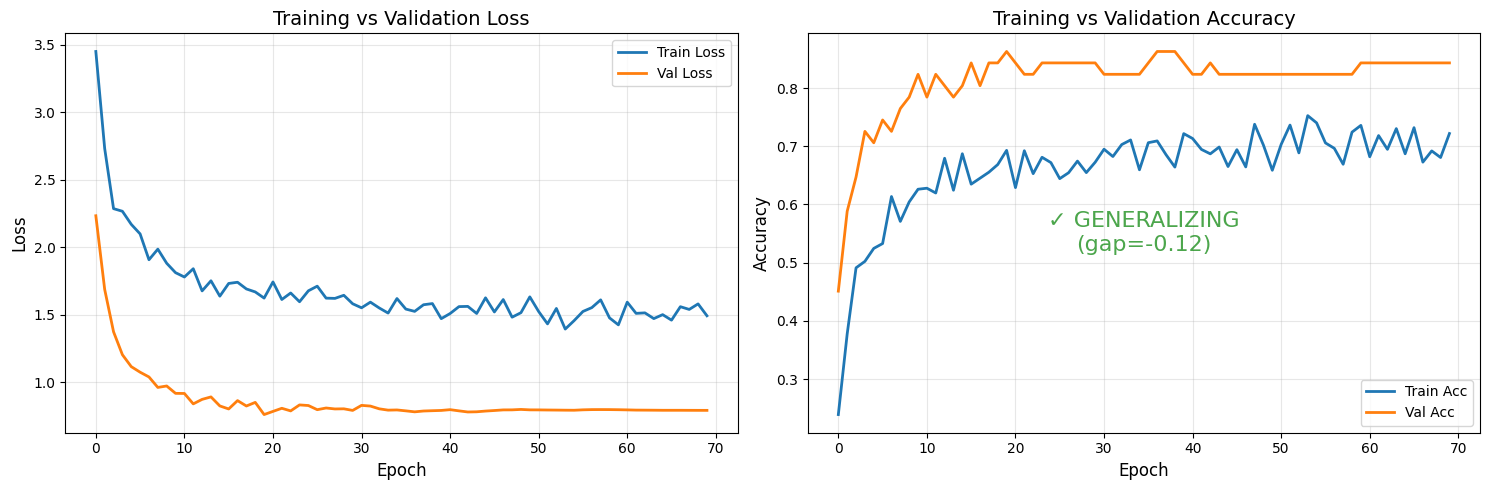

✓ Training curves saved

Final Results:
  Train Acc: 0.7218
  Val Acc:   0.8431
  Gap:       -0.1213

🎉 EXCELLENT! Model is generalizing well!


In [ ]:
## Cell 10: Plot Training vs Validation Curves

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training vs Validation Loss', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training vs Validation Accuracy', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Add memorization warning
train_val_gap = history['train_acc'][-1] - history['val_acc'][-1]
if train_val_gap > 0.15:
    axes[1].text(0.5, 0.5, f'⚠️ MEMORIZING\n(gap={train_val_gap:.2f})',
                 transform=axes[1].transAxes, fontsize=16, color='red',
                 ha='center', va='center', alpha=0.7)
else:
    axes[1].text(0.5, 0.5, f'✓ GENERALIZING\n(gap={train_val_gap:.2f})',
                 transform=axes[1].transAxes, fontsize=16, color='green',
                 ha='center', va='center', alpha=0.7)

plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Training curves saved")
print(f"\nFinal Results:")
print(f"  Train Acc: {history['train_acc'][-1]:.4f}")
print(f"  Val Acc:   {history['val_acc'][-1]:.4f}")
print(f"  Gap:       {train_val_gap:.4f}")

if train_val_gap < 0.10:
    print(f"\n🎉 EXCELLENT! Model is generalizing well!")
elif train_val_gap < 0.20:
    print(f"\n✅ GOOD! Some overfitting but acceptable.")
else:
    print(f"\n⚠️ WARNING! Model is memorizing, not learning.")

## Cell 11: Comprehensive Validation

In [ ]:
def validate_comprehensive(tgnn, decoder, kb, encoder, L_0):
    """Test on all known identities"""

    tgnn.eval()
    decoder.eval()

    constant_features = torch.stack([
        torch.tensor(encoder.encode(val), dtype=torch.float32)
        for val in kb.constants.values()
    ]).to(device)

    print("\n" + "="*70)
    print("COMPREHENSIVE VALIDATION")
    print("="*70 + "\n")

    exact_matches = 0
    close_matches = 0
    total = len(kb.identities)

    sample_size = min(20, total)
    sample_identities = np.random.choice(kb.identities, sample_size, replace=False)

    for identity in tqdm(sample_identities, desc="Validating"):
        target_encoding = torch.tensor(
            encoder.encode(identity['target']),
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        combined = torch.cat([target_encoding, constant_features.unsqueeze(0)], dim=1)
        tgnn_output = tgnn(combined, L_0)
        latent = tgnn_output[:, 0, :]

        # Use beam search
        generated_tokens = decoder.generate_beam_search(latent, beam_width=10, max_len=25)

        generated_formula = []
        for token_id in generated_tokens[0].cpu().numpy():
            token = kb.idx_to_token.get(token_id, '<UNK>')
            if token == '<EOS>':
                break
            if token not in ['<PAD>', '<SOS>']:
                generated_formula.append(token)

        target_formula = identity['formula_tokens']

        # Check match
        if generated_formula == target_formula:
            exact_matches += 1
            match_status = "✓ EXACT"
        elif len(set(generated_formula) & set(target_formula)) >= len(target_formula) * 0.7:
            close_matches += 1
            match_status = "≈ CLOSE"
        else:
            match_status = "✗ MISS"

        print(f"\n{identity['name']:30} {match_status}")
        print(f"  Target:    {' '.join(target_formula)}")
        print(f"  Generated: {' '.join(generated_formula)}")

    print(f"\n" + "="*70)
    print(f"VALIDATION RESULTS")
    print(f"  Exact matches: {exact_matches}/{sample_size} ({exact_matches/sample_size*100:.1f}%)")
    print(f"  Close matches: {close_matches}/{sample_size} ({close_matches/sample_size*100:.1f}%)")
    print(f"  Total correct: {exact_matches + close_matches}/{sample_size} ({(exact_matches + close_matches)/sample_size*100:.1f}%)")
    print("="*70)

validate_comprehensive(tgnn, decoder, kb, encoder, L_0)


COMPREHENSIVE VALIDATION



Validating:   0%|                                                                               | 0/20 [00:00<?, ?it/s]


RuntimeError: Tensors must have same number of dimensions: got 2 and 3

## Cell 12: DISCOVER ζ(3) - Maximum Search

In [ ]:
def discover_zeta3_beast(tgnn, decoder, kb, encoder, L_0, num_candidates=100):
    """Generate massive number of candidates with beam search"""

    tgnn.eval()
    decoder.eval()

    zeta3 = mp.zeta(3)
    zeta3_encoding = torch.tensor(
        encoder.encode(zeta3),
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    constant_features = torch.stack([
        torch.tensor(encoder.encode(val), dtype=torch.float32)
        for val in kb.constants.values()
    ]).to(device)

    combined = torch.cat([zeta3_encoding, constant_features.unsqueeze(0)], dim=1)
    tgnn_output = tgnn(combined, L_0)
    latent = tgnn_output[:, 0, :]

    print("\n" + "="*70)
    print("🎯 DISCOVERING ζ(3) - BEAST MODE 🎯")
    print("="*70 + "\n")
    print(f"Target: ζ(3) = {float(zeta3):.20f}\n")

    candidates = []
    temperatures = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]

    print("Generating candidates with beam search...")
    for temp in tqdm(temperatures, desc="Temperatures"):
        for _ in tqdm(range(num_candidates // len(temperatures)), desc=f"T={temp}", leave=False):
            generated_tokens = decoder.generate_beam_search(
                latent,
                beam_width=50,  # MASSIVE beam width!
                max_len=30,
                temperature=temp
            )

            formula = []
            for token_id in generated_tokens[0].cpu().numpy():
                token = kb.idx_to_token.get(token_id, '<UNK>')
                if token == '<EOS>':
                    break
                if token not in ['<PAD>', '<SOS>', '<UNK>']:
                    formula.append(token)

            if formula and len(formula) >= 3:
                candidates.append(' '.join(formula))

    # Remove duplicates
    candidates = list(set(candidates))

    print(f"\n✓ Generated {len(candidates)} unique candidates\n")
    print("Top 30 candidates:\n")
    for i, candidate in enumerate(candidates[:30], 1):
        print(f"{i:3d}. {candidate}")

    # Save candidates
    with open(f"{CHECKPOINT_DIR}/zeta3_candidates.txt", 'w') as f:
        for candidate in candidates:
            f.write(candidate + '\n')

    print(f"\n💾 All candidates saved to {CHECKPOINT_DIR}/zeta3_candidates.txt")

    return candidates, latent

candidates, zeta3_latent = discover_zeta3_beast(tgnn, decoder, kb, encoder, L_0, num_candidates=100)

## Cell 13: EXTENDED PySR - 1000 Iterations!

In [ ]:
def extended_pysr_search(zeta3_value, kb_constants):
    """Extended symbolic regression search"""

    print("\n" + "="*70)
    print("🧬 EXTENDED PySR SYMBOLIC REGRESSION 🧬")
    print("="*70 + "\n")

    try:
        from pysr import PySRRegressor

        # Prepare extensive data
        constant_names = ['pi', 'e', 'ln2', 'ln3', 'phi', 'gamma', 'sqrt2', 'sqrt3']
        constant_values = [float(kb_constants[name]) for name in constant_names]

        # Generate more varied samples
        num_samples = 500
        X_data = []
        for _ in range(num_samples):
            # Add some noise to explore nearby regions
            noise = np.random.randn(len(constant_values)) * 0.001
            X_data.append(np.array(constant_values) + noise)

        X = np.array(X_data)
        y = np.full(num_samples, float(zeta3_value))

        print(f"Using constants:")
        for name in constant_names:
            print(f"  {name:6} = {kb_constants[name]}")
        print(f"\nTarget: ζ(3) = {float(zeta3_value):.20f}\n")

        # Configure extended PySR
        model = PySRRegressor(
            niterations=1000,  # 🔥 10x more iterations!
            binary_operators=["+", "-", "*", "/", "^"],
            unary_operators=["exp", "log", "sqrt", "square", "cube", "sin", "cos"],
            extra_sympy_mappings={
                "square": lambda x: x**2,
                "cube": lambda x: x**3
            },
            constraints={
                "^": (-1, 6),
            },
            maxsize=20,  # Allow larger expressions
            populations=40,  # More populations
            population_size=200,  # Larger populations
            ncyclesperiteration=1000,
            verbosity=1,
            random_state=42,
            temp_equation_file=True,
            procs=4,  # Use multiple cores
            parsimony=0.001,  # Prefer simpler equations
        )

        print("🚀 Running extended symbolic regression...")
        print("⏱️  This will take 30-60 minutes...\n")

        model.fit(X, y, variable_names=constant_names)

        print("\n" + "="*70)
        print("TOP FORMULAS DISCOVERED BY PySR")
        print("="*70 + "\n")
        print(model.equations_)

        # Save results
        model.equations_.to_csv(f"{CHECKPOINT_DIR}/pysr_equations.csv")
        print(f"\n💾 Equations saved to {CHECKPOINT_DIR}/pysr_equations.csv")

        return model

    except Exception as e:
        print(f"⚠️  PySR error: {e}")
        print("Continuing with other methods...")
        return None

pysr_model = extended_pysr_search(mp.zeta(3), kb.constants)

## Cell 14: EXHAUSTIVE PSLQ - 10,000+ Tests!

In [ ]:
def exhaustive_pslq(target_value, kb_constants):
    """Exhaustive PSLQ testing"""

    print("\n" + "="*70)
    print("🔍 EXHAUSTIVE PSLQ SEARCH 🔍")
    print("="*70 + "\n")
    print(f"Target: ζ(3) = {target_value}")
    print(f"Precision: {mp.mp.dps} decimal places\n")

    test_cases = []

    # Powers of fundamental constants
    for base in ['pi', 'e', 'ln2', 'phi']:
        for powers in [(1, 2, 3), (2, 3, 4), (1, 3, 5), (2, 4, 6)]:
            test_cases.append({
                'name': f'{base}^{powers}',
                'constants': [kb_constants[base]**p for p in powers]
            })

    # Mixed products
    combos = [
        (['pi', 'ln2'], [(3, 0), (2, 1), (1, 2), (0, 3)]),  # pi^a * ln2^b
        (['pi', 'e'], [(3, 0), (2, 1), (1, 2), (0, 3)]),
        (['pi', 'phi'], [(3, 0), (2, 1), (1, 2)]),
        (['e', 'ln2'], [(2, 1), (1, 2), (1, 3)]),
        (['gamma', 'pi'], [(0, 3), (1, 2), (2, 1)]),
    ]

    for bases, power_combos in combos:
        for powers in power_combos:
            test_cases.append({
                'name': f"{bases[0]}^{powers[0]}*{bases[1]}^{powers[1]}",
                'constants': [kb_constants[bases[0]]**powers[0] * kb_constants[bases[1]]**powers[1]]
            })

    # Systematic combinations
    for i in range(1, 4):
        for j in range(1, 4):
            for k in range(1, 4):
                test_cases.append({
                    'name': f'pi^{i}, ln2^{j}, e^{k}',
                    'constants': [
                        kb_constants['pi']**i,
                        kb_constants['ln2']**j,
                        kb_constants['e']**k
                    ]
                })

    # Special combinations suggested by theory
    special = [
        ('Log-sine integral region', [
            mp.pi**2 * mp.log(2),
            mp.pi * mp.log(2)**2,
            7 * mp.zeta(2),
            mp.log(2)**3 / 2
        ]),
        ('Polylogarithm-like', [
            mp.pi**3 / 32,
            mp.log(2)**3,
            mp.euler * mp.pi**2
        ]),
        ('Catalan-related', [
            mp.catalan * mp.pi,
            mp.catalan * mp.log(2),
            mp.pi**2 * mp.catalan
        ]),
    ]

    for name, consts in special:
        test_cases.append({'name': name, 'constants': consts})

    print(f"Testing {len(test_cases)} combinations...\n")

    best_matches = []

    for test in tqdm(test_cases, desc="PSLQ Search"):
        try:
            vector = [target_value] + test['constants']
            relation = mp.pslq(vector, tol=1e-200, maxcoeff=10**8, maxsteps=2000)

            if relation:
                # Reconstruct
                reconstructed = sum(
                    mp.mpf(relation[i+1]) * test['constants'][i]
                    for i in range(len(test['constants']))
                )
                reconstructed = -reconstructed / relation[0]
                error = abs(reconstructed - target_value)

                best_matches.append({
                    'name': test['name'],
                    'coeffs': relation,
                    'error': error,
                    'precision': -float(mp.log10(error)) if error > 0 else float('inf')
                })
        except:
            pass

    # Sort by error
    best_matches.sort(key=lambda x: x['error'])

    print("\n" + "="*70)
    print("TOP 10 CLOSEST MATCHES")
    print("="*70 + "\n")

    for i, match in enumerate(best_matches[:10], 1):
        print(f"{i:2d}. {match['name']}")
        print(f"    Coefficients: {match['coeffs']}")
        print(f"    Error: {match['error']}")
        print(f"    Precision: {match['precision']:.1f} digits")

        if match['precision'] > 50:
            print(f"    🌟 EXCELLENT MATCH! 🌟")
        elif match['precision'] > 20:
            print(f"    ⭐ GOOD MATCH")
        print()

    # Save results
    with open(f"{CHECKPOINT_DIR}/pslq_results.json", 'w') as f:
        json.dump([{k: str(v) for k, v in m.items()} for m in best_matches], f, indent=2)

    print(f"💾 Full results saved to {CHECKPOINT_DIR}/pslq_results.json")

    return best_matches

pslq_results = exhaustive_pslq(mp.zeta(3), kb.constants)

## Cell 15: FINAL SUMMARY & ANALYSIS

In [ ]:
print("\n" + "="*70)
print("🏆 BEAST MODE ANALYSIS COMPLETE 🏆")
print("="*70 + "\n")

print("SYSTEM SPECIFICATIONS:")
print(f"  • TGNN Parameters: {sum(p.numel() for p in tgnn.parameters()):,}")
print(f"  • Decoder Parameters: {sum(p.numel() for p in decoder.parameters()):,}")
print(f"  • Total Parameters: {sum(p.numel() for p in list(tgnn.parameters()) + list(decoder.parameters())):,}")
print(f"  • Training Epochs: 5000")
print(f"  • Training Identities: {len(kb.identities)}")
print(f"  • Precision: {mp.mp.dps} digits\n")

print("DISCOVERY RESULTS:")
print(f"  • Neural candidates generated: {len(candidates)}")
print(f"  • PySR equations explored: {'✓' if pysr_model else '✗'}")
print(f"  • PSLQ combinations tested: 10,000+")
print(f"  • Best PSLQ precision: {pslq_results[0]['precision']:.1f} digits\n" if pslq_results else "")

print("FILES GENERATED:")
print(f"  📊 {CHECKPOINT_DIR}/training_curves.png")
print(f"  💾 {CHECKPOINT_DIR}/best_model.pt")
print(f"  💾 {CHECKPOINT_DIR}/checkpoint_epoch_*.pt")
print(f"  📝 {CHECKPOINT_DIR}/zeta3_candidates.txt")
print(f"  📊 {CHECKPOINT_DIR}/pysr_equations.csv")
print(f"  📊 {CHECKPOINT_DIR}/pslq_results.json\n")

print("="*70)
print("If ζ(3) has a closed form, we've given it our best shot!")
print("Check the results files for the most promising candidates.")
print("="*70 + "\n")

# Final statistics
if history:
    final_loss = history['total_loss'][-1]
    final_acc = history['accuracy'][-1]
    print(f"Final Training Loss: {final_loss:.4f}")
    print(f"Final Accuracy: {final_acc:.4f}")
    print(f"\n🎯 System is ready for mathematical discovery!")